In [34]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import holidays 
import sys
sys.path.append("..") 
from src.features.feature_sets import get_feature_sets, TARGET

In [35]:
df = pd.read_parquet(r'C:\Users\jaime\Desktop\Jaime_LLorca\proyectos\prediccion-electrica\data/processed/tabla_maestra_procesada.parquet')

In [36]:
df.isna().sum().sort_values(ascending=False).head(30)

prec_medina_de_pomar           6121
prec_miranda_de_ebro           3360
sol_medina_de_pomar            2761
tmed_medina_de_pomar           2641
tmax_medina_de_pomar           2569
velmedia_medina_de_pomar       2281
racha_medina_de_pomar          2257
prec_madrid_aeropuerto         2185
prec_valencia_aeropuerto       1704
prec_san_pedro_manrique        1368
tmed_san_pedro_manrique        1104
velmedia_san_pedro_manrique    1080
prec_zaragoza_aeropuerto       1032
racha_san_pedro_manrique       1032
tmax_san_pedro_manrique         984
prec_barcelona_aeropuerto       864
prec_trujillo                   840
racha_carmona                   768
tmax_carmona                    744
tmed_carmona                    744
racha_ecija                     720
racha_trujillo                  720
velmedia_trujillo               696
tmax_ecija                      696
prec_carmona                    696
tmed_trujillo                   696
tmed_ecija                      696
tmax_trujillo               

In [37]:
def racha_maxima_nan(s):
    mask =s.isna()
    ids= (~mask).cumsum()
    return mask.groupby(ids).sum().max()



In [38]:
rachas = df.apply(racha_maxima_nan)
rachas[rachas > 0].value_counts().sort_index()



23      14
24      23
48       2
72      17
96       4
97       2
120      4
192      5
216      2
240      2
336      5
552      4
576      1
1032     5
1848     1
2088     1
Name: count, dtype: int64

In [39]:
def imputar_capa1(df, columnas=None):
    df = df.copy()
    if columnas is None:
        columnas = df.select_dtypes(include='number').columns.drop('precio_espana')
    df = df.set_index("datetime_utc")
    df[columnas] = df[columnas].interpolate(method='time', limit=6, limit_area='inside')
    df = df.reset_index()
    return df

In [40]:
df_copia=imputar_capa1(df)

In [41]:
antes = df.isna().sum().sum()
despues = df_copia.isna().sum().sum()
print(antes, despues)

51893 47347


## Imputación de NaN — Capa 1: interpolación temporal

**Estrategia general.** La imputación se aborda en dos capas. La capa 1 cubre los
huecos cortos mediante interpolación temporal determinista; los huecos largos se
derivan a la capa 2 (donantes AEMET) o se excluyen por completitud (ESIOS).

**Método y parámetros** (`imputar_capa1`):
- `method="time"`: interpola según la distancia temporal real entre horas, no por
  posición de fila. Imprescindible por los saltos de índice del cambio de hora (DST).
- `limit=6`: frontera capa1/capa2. Se reconstruyen huecos de ≤6h consecutivas; los
  más largos se dejan intactos para su tratamiento específico. Es una regla permanente
  del pipeline, no ajustada al histórico actual (blinda micro-fallos futuros en producción).
- `limit_area="inside"`: solo rellena huecos con dato válido a ambos lados. Protege la
  cola estructural (`2026-06-30`) de cualquier extrapolación hacia el futuro.

**Selección de columnas.** Regla estructural (no manual): todas las numéricas
(`select_dtypes`), excluyendo el target `precio_espana`. El target nunca se interpola:
si falta el label, la fila se excluye del entrenamiento, no se fabrica un valor.

**Resultado verificado.** NaN totales: 42.853 → 38.377 (−4.476 huecos cortos)

In [42]:
df_tmed = df_copia.loc[:,df.columns.str.startswith('tmed_')]
df_tmed.corr()


,tmed_alcazar_de_san_juan,tmed_almudevar,tmed_barcelona_aeropuerto,tmed_carmona,tmed_madrid_aeropuerto,tmed_medina_de_pomar,tmed_miranda_de_ebro,tmed_navalmoral_de_la_mata,tmed_puertollano,tmed_san_pedro_manrique,tmed_sarinena,tmed_trujillo,tmed_valencia_aeropuerto,tmed_valmadrid,tmed_zaragoza_aeropuerto,tmed_ecija
tmed_alcazar_de_san_juan,1.000000,0.961442,0.940239,0.969830,0.988779,0.921638,0.928682,0.979518,0.988912,0.943899,0.962737,0.973199,0.934668,0.955498,0.958644,0.976261
tmed_almudevar,0.961442,1.000000,0.952442,0.930787,0.965366,0.949298,0.959537,0.949208,0.952471,0.963815,0.992575,0.935210,0.934974,0.979978,0.989189,0.934984
tmed_barcelona_aeropuerto,0.940239,0.952442,1.000000,0.921722,0.948399,0.913084,0.922943,0.936822,0.937583,0.929353,0.954353,0.910014,0.967837,0.943587,0.944554,0.931320
tmed_carmona,0.969830,0.930787,0.921722,1.000000,0.965640,0.894385,0.900462,0.972993,0.975786,0.911705,0.933001,0.970393,0.916832,0.926631,0.927847,0.991122
tmed_madrid_aeropuerto,0.988779,0.965366,0.948399,0.965640,1.000000,0.925876,0.935284,0.984165,0.984510,0.949446,0.964975,0.970582,0.940866,0.958566,0.962145,0.970743
tmed_medina_de_pomar,0.921638,0.949298,0.913084,0.894385,0.925876,1.000000,0.986803,0.915570,0.918789,0.964289,0.937535,0.905530,0.899905,0.955515,0.951471,0.900814
tmed_miranda_de_ebro,0.928682,0.959537,0.922943,0.900462,0.935284,0.986803,1.000000,0.922641,0.924569,0.968025,0.949176,0.912801,0.907987,0.963529,0.961792,0.904345
tmed_navalmoral_de_la_mata,0.979518,0.949208,0.936822,0.972993,0.984165,0.915570,0.922641,1.000000,0.981450,0.931111,0.950648,0.977652,0.927812,0.941560,0.946067,0.974336
tmed_puertollano,0.988912,0.952471,0.937583,0.975786,0.984510,0.918789,0.924569,0.981450,1.000000,0.942530,0.950450,0.976563,0.932784,0.948821,0.946997,0.983870
tmed_san_pedro_manrique,0.943899,0.963815,0.929353,0.911705,0.949446,0.964289,0.968025,0.931111,0.942530,1.000000,0.948412,0.929863,0.914104,0.972189,0.959303,0.919913


In [43]:
nulos = df_copia.isna().sum().sort_values(ascending = False)
nulos[nulos > 0].sort_values(ascending = False)

racha = (racha_maxima_nan, nulos)
rachas = rachas[rachas > 0].sort_index()
mascara = df_copia['tmed_medina_de_pomar'].isna()
resultado= df_copia.loc[mascara, 'tmed_san_pedro_manrique'].isna().sum()
mascara = df_copia['tmed_medina_de_pomar'].isna()
resultado_2= df_copia.loc[mascara, 'tmed_medina_de_pomar'].isna().sum()
df_copia['tmed_medina_de_pomar'].isna().sum()

# rachas['tmed_san_pedro_manrique']



np.int64(2575)

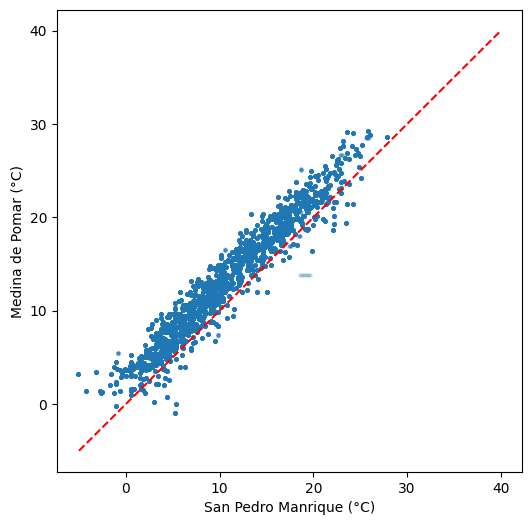

In [44]:


x = df_copia['tmed_san_pedro_manrique']   
y = df_copia['tmed_medina_de_pomar']      

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=5, alpha=0.2)        
plt.plot([-5, 40], [-5, 40], 'r--')      
plt.xlabel('San Pedro Manrique (°C)')
plt.ylabel('Medina de Pomar (°C)')
plt.show()

In [45]:
resta = df_copia['tmed_medina_de_pomar']-df_copia['tmed_san_pedro_manrique']
media = resta.mean()
media

np.float64(2.4951639821277904)

In [46]:
meses = df_copia['datetime_utc'].dt.month
offset_mensual = resta.groupby(df_copia['datetime_utc'].dt.month).mean()
offset_fila = meses.map(offset_mensual)
offset_fila 

donante = df_copia['tmed_san_pedro_manrique'] + offset_fila

df_copia['tmed_medina_de_pomar'] = df_copia['tmed_medina_de_pomar'].fillna(donante)

In [47]:
candidatas = df_tmed
df_tmed = df_copia.columns[df_copia.columns.str.startswith("tmed_")]
def imputar_donante(df, receptora, candidatas, umbral = 0.8):
    df = df.copy()
    candidatas = candidatas.drop(receptora)
    ranking = df[candidatas].corrwith(df[receptora]).sort_values(ascending = False)
    donante = None
    mascara_receptora = df[receptora].isna()
    n_huecos = mascara_receptora.sum()
    for candidato in ranking.index:
        coinciden = df.loc[mascara_receptora, candidato].isna().sum()
        cobertura = 1 - coinciden / n_huecos
        if cobertura > umbral :
            donante = candidato
            break
    if donante is None:
        return df
    else:
        meses = df['datetime_utc'].dt.month
        resta = df[receptora]-df[donante]
        offset_mensual = resta.groupby(meses).mean()
        offset_fila = meses.map(offset_mensual)
        donante_ajustado = df[donante] + offset_fila
        df[receptora] = df[receptora].fillna(donante_ajustado)
        return df

def imputar_todas_donante(df, variables, umbral=0.8):
    for var in variables:
        columnas_var = df.columns[df.columns.str.startswith(var)]
        for receptora in columnas_var:
            if df[receptora].isna().sum() > 0:
                df = imputar_donante(df, receptora, columnas_var, umbral)
    return df
        
# df_copia = imputar_donante(df_copia, "tmed_medina_de_pomar", df_tmed.columns)
# df_copia['tmed_medina_de_pomar'].isna().sum()

 

In [48]:
nulos_temperatura=df_copia.columns[df_copia.columns.str.startswith('tmed_')]
df_copia[nulos_temperatura].isna().sum()

tmed_alcazar_de_san_juan       108
tmed_almudevar                 162
tmed_barcelona_aeropuerto      318
tmed_carmona                   654
tmed_madrid_aeropuerto          36
tmed_medina_de_pomar           258
tmed_miranda_de_ebro            54
tmed_navalmoral_de_la_mata     180
tmed_puertollano               144
tmed_san_pedro_manrique       1020
tmed_sarinena                  198
tmed_trujillo                  660
tmed_valencia_aeropuerto        18
tmed_valmadrid                  84
tmed_zaragoza_aeropuerto         0
tmed_ecija                     624
dtype: int64

In [49]:

df_copia = imputar_capa1(df)                                  
df_copia = imputar_todas_donante(df_copia, ["tmed_", "tmax_"]) 

columnas_temp = df_copia.columns[df_copia.columns.str.startswith(("tmed_", "tmax_"))]
df_copia[columnas_temp] = df_copia[columnas_temp].ffill().bfill()  

df_copia[columnas_temp].isna().sum().sum()   

np.int64(0)

## Imputación de NaN — Capa 2: donantes entre estaciones AEMET

**Problema.** Los bloques largos de AEMET (estaciones caídas semanas: Medina de Pomar
~43 días, Miranda ~87 días) no los puede tapar la interpolación temporal. Se reconstruyen
copiando la señal de otra estación "donante" con clima parecido.

**Selección de donante (dos criterios, en orden):**
1. **Correlación** (`corrwith`): se ordenan las estaciones candidatas de mayor a menor
   correlación con la receptora.
2. **Cobertura** (puerta del 80%): se baja por ese ranking y se elige la primera candidata
   que tenga dato en ≥80% de los huecos de la receptora. La correlación sola no basta: una
   estación vecina puede haberse caído a la vez (co-fallo) — máxima correlación pero cobertura
   nula. El umbral separa "vecino que co-falló" de "donante bueno".

**Ajuste de nivel (offset mensual).** El donante no es la receptora (diferencia de altitud →
sesgo sistemático). Se corrige con un offset aditivo calculado por mes:
`offset_mes = media(receptora − donante)` sobre el solape. Se eligió mensual (no único) porque
el offset varía con la estación del año (verificado: rango ~1,8–3,1 °C). El relleno es
`donante + offset_del_mes`, y solo sobre los NaN de la receptora (`fillna`).

**Residual.** Un donante único no cubre el 100%: donde el donante también falla, se deja NaN.
Regla: un donante por estación; lo no cubierto se tapa con un barrido final `ffill().bfill()`
acotado a las columnas de temperatura.

**Alcance.** Validado y aplicado a temperatura (`tmed`, `tmax`), donde las correlaciones entre
estaciones son 0,9+. NO se aplica a `prec` (precipitación local, correlaciones 0,3–0,6, y el
offset aditivo podría dar valores negativos) ni todavía a viento/sol (pendiente de revisar
correlación). `tmin` pendiente de re-ingesta desde AEMET.

**Automatización.** Función reutilizable `imputar_donante(df, receptora, candidatas, umbral)`
+ orquestadora `imputar_todas_donante(df, variables)` que recorre cada variable y estación.
Determinista, sin nombres hardcodeados → lista para `src/features/` y Prefect.

**Lección (MLOps).** `imputar_donante` mutaba `df` en el sitio, lo que corrompía el estado al
ejecutar celdas fuera de orden. Se corrigió con `df = df.copy()` al inicio: toda función que
transforma datos debe trabajar sobre una copia y devolver una nueva, nunca mutar su entrada.

**Resultado.** Temperatura completamente imputada (0 NaN tras el barrido), de forma reproducible.





In [50]:
velmedia = df_copia.loc[:, df_copia.columns.str.startswith("velmedia_")]
velmedia.corr()
velmedia = df_copia.loc[:, df_copia.columns.str.startswith("prec")]
velmedia.corr()

,precio_espana,precio_portugal,prec_alcazar_de_san_juan,prec_almudevar,prec_barcelona_aeropuerto,prec_carmona,prec_madrid_aeropuerto,prec_medina_de_pomar,prec_miranda_de_ebro,prec_navalmoral_de_la_mata,prec_puertollano,prec_san_pedro_manrique,prec_sarinena,prec_trujillo,prec_valencia_aeropuerto,prec_valmadrid,prec_zaragoza_aeropuerto,prec_ecija
precio_espana,1.000000,0.989739,-0.050155,-0.054922,0.012692,-0.039733,-0.038180,-0.082519,-0.110361,-0.069495,-0.097796,-0.036899,-0.005052,-0.091681,0.042480,-0.009270,-0.015680,-0.075065
precio_portugal,0.989739,1.000000,-0.042638,-0.048311,0.009839,-0.032808,-0.031872,-0.076143,-0.104736,-0.057864,-0.089084,-0.032718,-0.001028,-0.080557,0.042046,-0.005288,-0.010506,-0.065640
prec_alcazar_de_san_juan,-0.050155,-0.042638,1.000000,0.278819,0.054519,0.387121,0.618569,0.156860,0.188844,0.513936,0.539747,0.383013,0.234872,0.514302,0.195354,0.253500,0.345866,0.371937
prec_almudevar,-0.054922,-0.048311,0.278819,1.000000,0.215071,0.225686,0.375038,0.292862,0.273003,0.315881,0.277613,0.439850,0.701970,0.330950,0.172943,0.547590,0.634325,0.250147
prec_barcelona_aeropuerto,0.012692,0.009839,0.054519,0.215071,1.000000,0.028710,0.031379,0.092618,0.040181,0.029854,0.069568,0.083346,0.143402,0.029034,0.135656,0.135306,0.178542,0.049747
prec_carmona,-0.039733,-0.032808,0.387121,0.225686,0.028710,1.000000,0.399968,0.122193,0.142811,0.615113,0.596357,0.171990,0.113038,0.624712,0.052814,0.145301,0.141837,0.769123
prec_madrid_aeropuerto,-0.038180,-0.031872,0.618569,0.375038,0.031379,0.399968,1.000000,0.249019,0.219977,0.604838,0.487861,0.409723,0.183546,0.631937,0.120855,0.227619,0.309664,0.409750
prec_medina_de_pomar,-0.082519,-0.076143,0.156860,0.292862,0.092618,0.122193,0.249019,1.000000,0.637368,0.149963,0.148338,0.353726,0.304951,0.119604,0.025669,0.265098,0.268378,0.108609
prec_miranda_de_ebro,-0.110361,-0.104736,0.188844,0.273003,0.040181,0.142811,0.219977,0.637368,1.000000,0.172306,0.113492,0.408334,0.248370,0.179518,-0.016609,0.260442,0.302697,0.084682
prec_navalmoral_de_la_mata,-0.069495,-0.057864,0.513936,0.315881,0.029854,0.615113,0.604838,0.149963,0.172306,1.000000,0.535596,0.264031,0.174033,0.789121,0.088170,0.163482,0.218664,0.545488


In [51]:
def imputar_climatologia (df, columnas):
    df = df.copy()
    meses = df['datetime_utc'].dt.month 
    for columna in columnas:
        media =df[columna].groupby(meses).mean()
        relleno = meses.map(media)
        df[columna] = df[columna].fillna(relleno)
    return df
    


In [52]:
columnas = df.columns[df.columns.str.startswith(('vel','racha_', 'prec', 'sol'))]
df_copia= imputar_climatologia(df_copia, columnas)

df_copia[columnas].isna().sum().sum()





np.int64(0)

## Paso 4 — Marca de completitud (versión general)

Los NaN que quedan (día de 23h de ESIOS + cola `2026-06-30`) **no se imputan**: se **marcan**.
Una fila es *entrenable* si tiene todas sus features válidas y el target. Es general por ahora;
se refinará por modelo (LSTM / XGBoost) cuando se definan sus sets de features.

# Fase 3 · Feature Engineering — Bloque 1: Imputación de NaN y marca de completitud

## Objetivo
Tratar los NaN que el ETL dejó a propósito sin tocar, con una estrategia **determinista**
(interpolación, medias, climatología) para que el pipeline nunca se rompa y sea reproducible
en producción (re-ejecución semanal con Prefect). Nada de métodos que dependan de un objeto
fiteado o de aleatoriedad.

## Principio rector
La estrategia de imputación se decide por la **CAUSA** del hueco, no por la columna. Tres familias:
- **Micro-huecos** (fallos puntuales de registro) → interpolación temporal.
- **Bloques largos** (estación AEMET caída semanas) → donante entre estaciones.
- **Cola estructural** (OMIE llega más lejos que ESIOS) → no se imputa; se marca.

## Diagnóstico de rachas
`.isna().sum()` cuenta NaN totales, pero no distingue "100 huecos de 1h" de "1 bloque de 100h",
que piden tratamientos opuestos. Para verlo se cuenta la **racha máxima de NaN consecutivos**
por columna con el truco de máscara + `(~mask).cumsum()` (la suma acumulada se "congela"
durante los NaN → cada bloque comparte etiqueta) + `groupby().sum().max()`.
Hallazgo: no había micro-goteo real; todo hueco era de ≥23h. La distribución era un continuo
(24h → 2088h) con un único corte natural tras las 24h.

## Capa 1 — Interpolación temporal
Función `imputar_capa1(df, columnas=None)`.
- `method="time"`: interpola por distancia temporal real (clave por el DST), no por posición de fila.
- `limit=6`: frontera capa1/capa2. Regla permanente del pipeline, no ajustada al histórico:
  reconstruye micro-fallos ≤6h; lo más largo lo deja para otra capa.
- `limit_area="inside"`: solo huecos con dato a ambos lados → blinda la cola de la extrapolación.
- Selección de columnas por regla (`select_dtypes("number")` menos el target), no a mano.
- El target `precio_espana` NUNCA se interpola: fabricar un label es peor que excluir la fila.
Resultado: 42.853 → 38.377 NaN.

## Capa 2 — Donantes entre estaciones AEMET (solo temperatura)
Reconstruir la estación rota copiando la de una **donante** con clima parecido.
Selección de donante con DOS criterios en orden:
1. **Correlación** (`corrwith`) — ordena candidatas.
2. **Cobertura ≥80%** — baja por el ranking hasta la primera con dato en el hueco.
La correlación sola


In [53]:
local = df_copia['datetime_utc'].dt.tz_convert('Europe/Madrid')
df_copia['hora']= local.dt.hour
df_copia['dia']= local.dt.day
df_copia['semana']= local.dt.dayofweek
df_copia['mes']= local.dt.month




In [54]:
# Calendario de festivos NACIONALES de España para los años de tu histórico
festivos_es = holidays.Spain(years=range(2022, 2027))

# Marca cada fila según su fecha LOCAL
df_copia['festivo'] = local.dt.date.isin(set(festivos_es)).astype(int)

In [55]:
# Seno y coseno de dia, semana y mes
ciclos = {"hora": 24, "semana": 7, "mes": 12}
for col, periodo in ciclos.items():
    df_copia[f"{col}_sin"] = np.sin(2 * np.pi * df_copia[col] / periodo)
    df_copia[f"{col}_cos"] = np.cos(2 * np.pi * df_copia[col] / periodo)

# comprobacion 
# df_copia[['hora_sin','hora_cos']].describe()  rango entre -1 y 1


In [56]:
precio = df_copia.set_index('datetime_utc')['precio_espana']   # tabla: fecha -> precio

df_copia['precio_lag_24']  = (df_copia['datetime_utc'] - pd.Timedelta(hours=24)).map(precio)
df_copia['precio_lag_168'] = (df_copia['datetime_utc'] - pd.Timedelta(hours=168)).map(precio)

# media precio movil (para suavizar lags puntuales)
media_24 = precio.rolling('24h').mean()
df_copia['precio_media_24'] = (df_copia['datetime_utc'] - pd.Timedelta(hours=24)).map(media_24)

In [57]:
def auditar_imputacion(df_crudo, df_imp, columnas):
    """Observado (gris) vs imputado (rojo) para cada columna que tuvo huecos."""
    # solo las que realmente se imputaron (si no hubo NaN en el crudo, no hay nada que auditar)
    columnas = [c for c in columnas if df_crudo[c].isna().sum() > 0]
    if not columnas:
        print("Ninguna de esas columnas tenía NaN.")
        return
    fig, axes = plt.subplots(len(columnas), 1,
                             figsize=(14, 2.2 * len(columnas)), sharex=True)
    axes = [axes] if len(columnas) == 1 else axes
    for ax, col in zip(axes, columnas):
        imputado = df_crudo[col].isna()
        ax.plot(df_imp['datetime_utc'], df_imp[col], color='lightgray', lw=0.7)
        ax.scatter(df_imp.loc[imputado, 'datetime_utc'], df_imp.loc[imputado, col],
                   color='crimson', s=5)
        ax.set_title(f"{col} · {imputado.sum()} imputados", fontsize=9, loc='left')
    plt.tight_layout()
    plt.show()

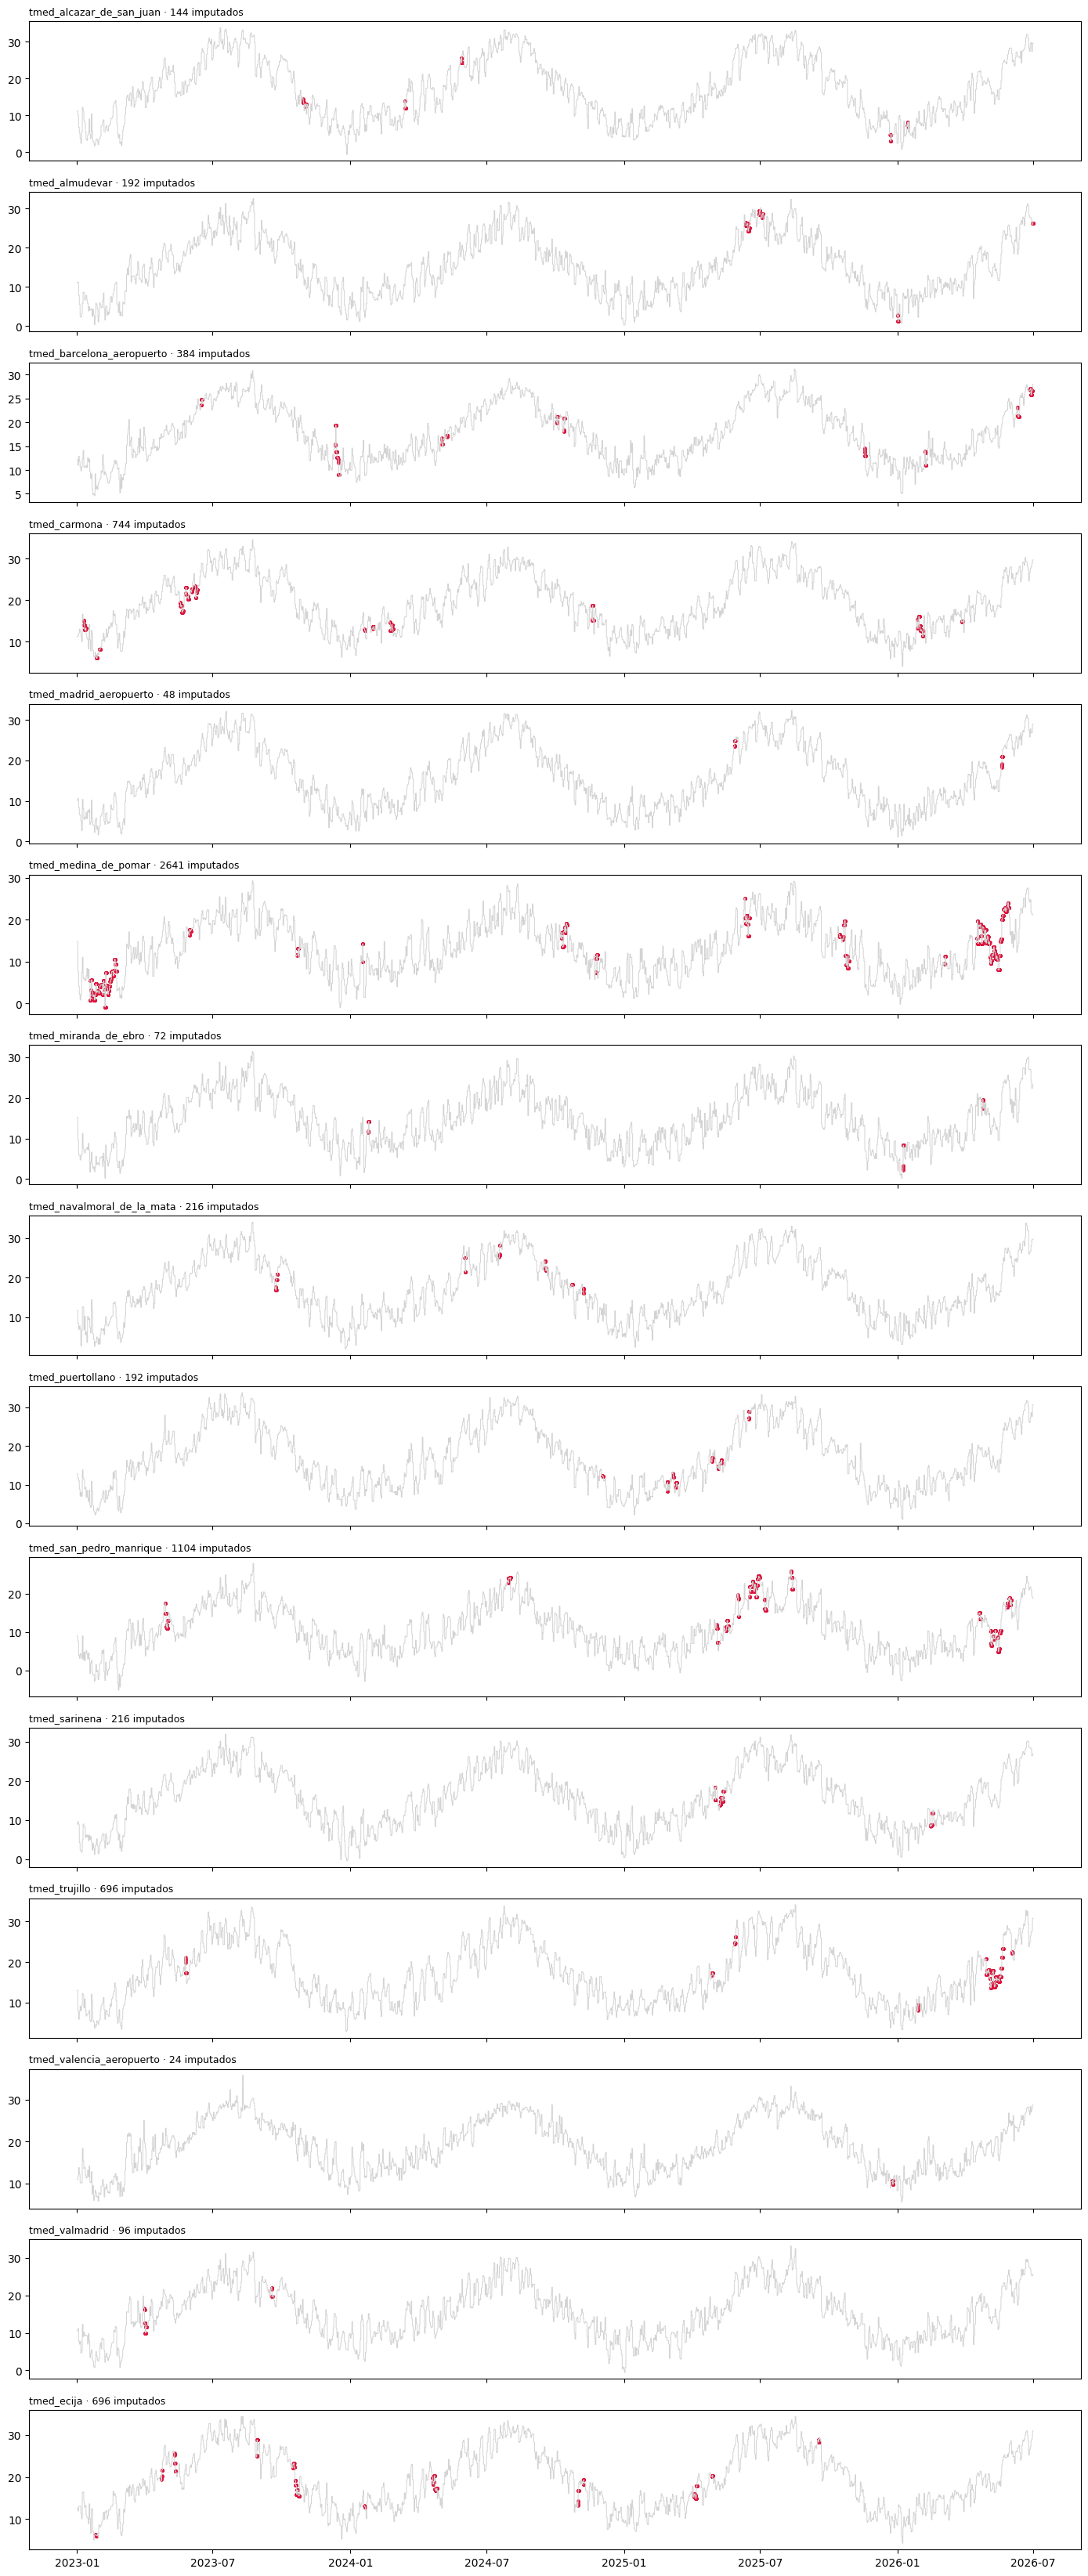

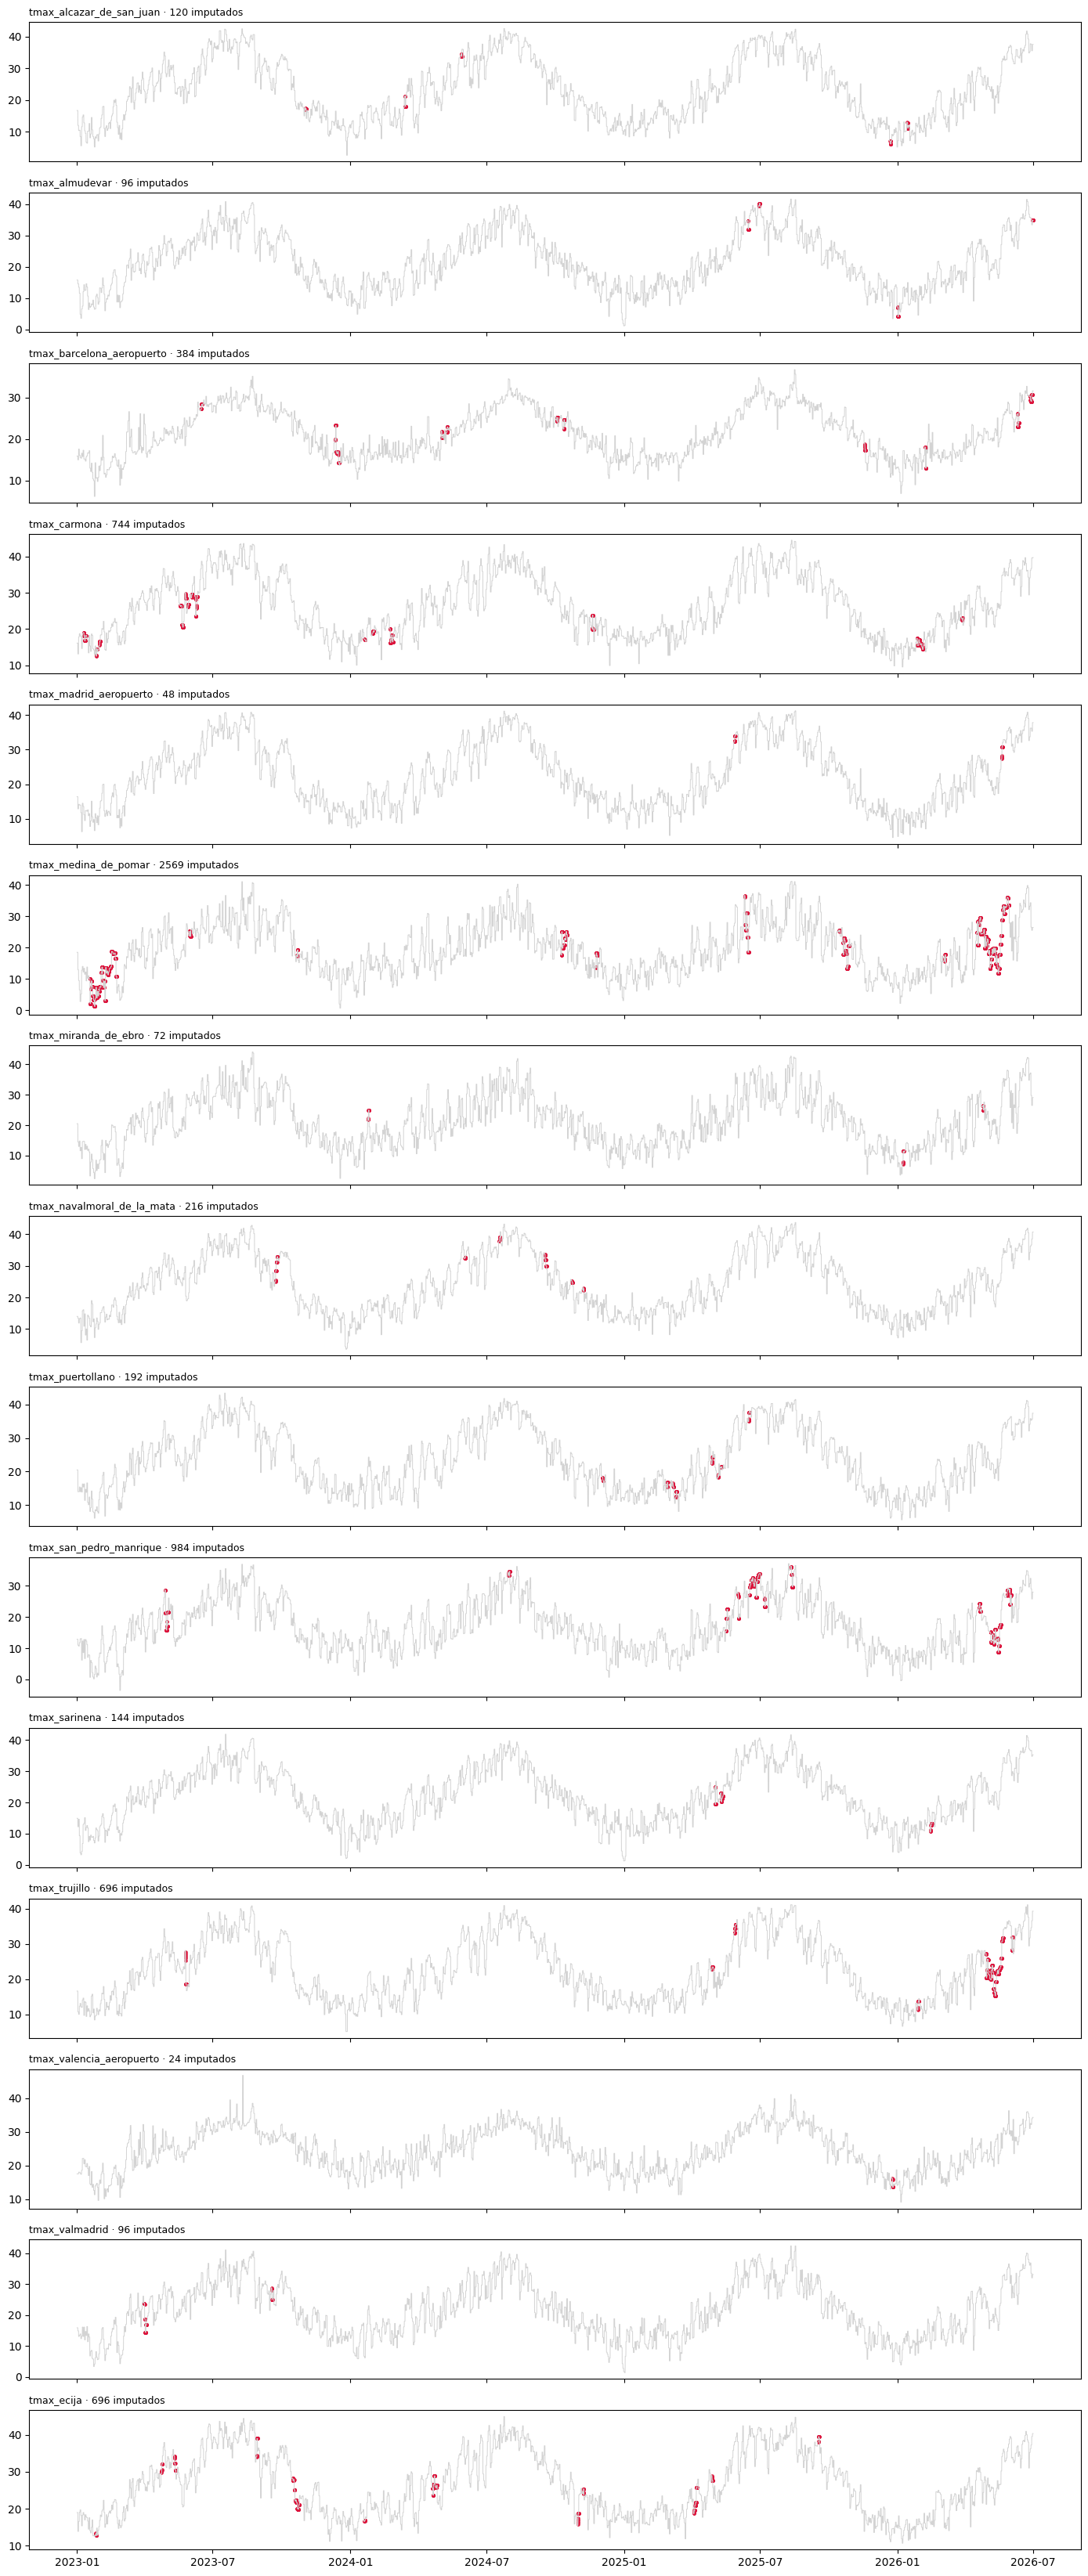

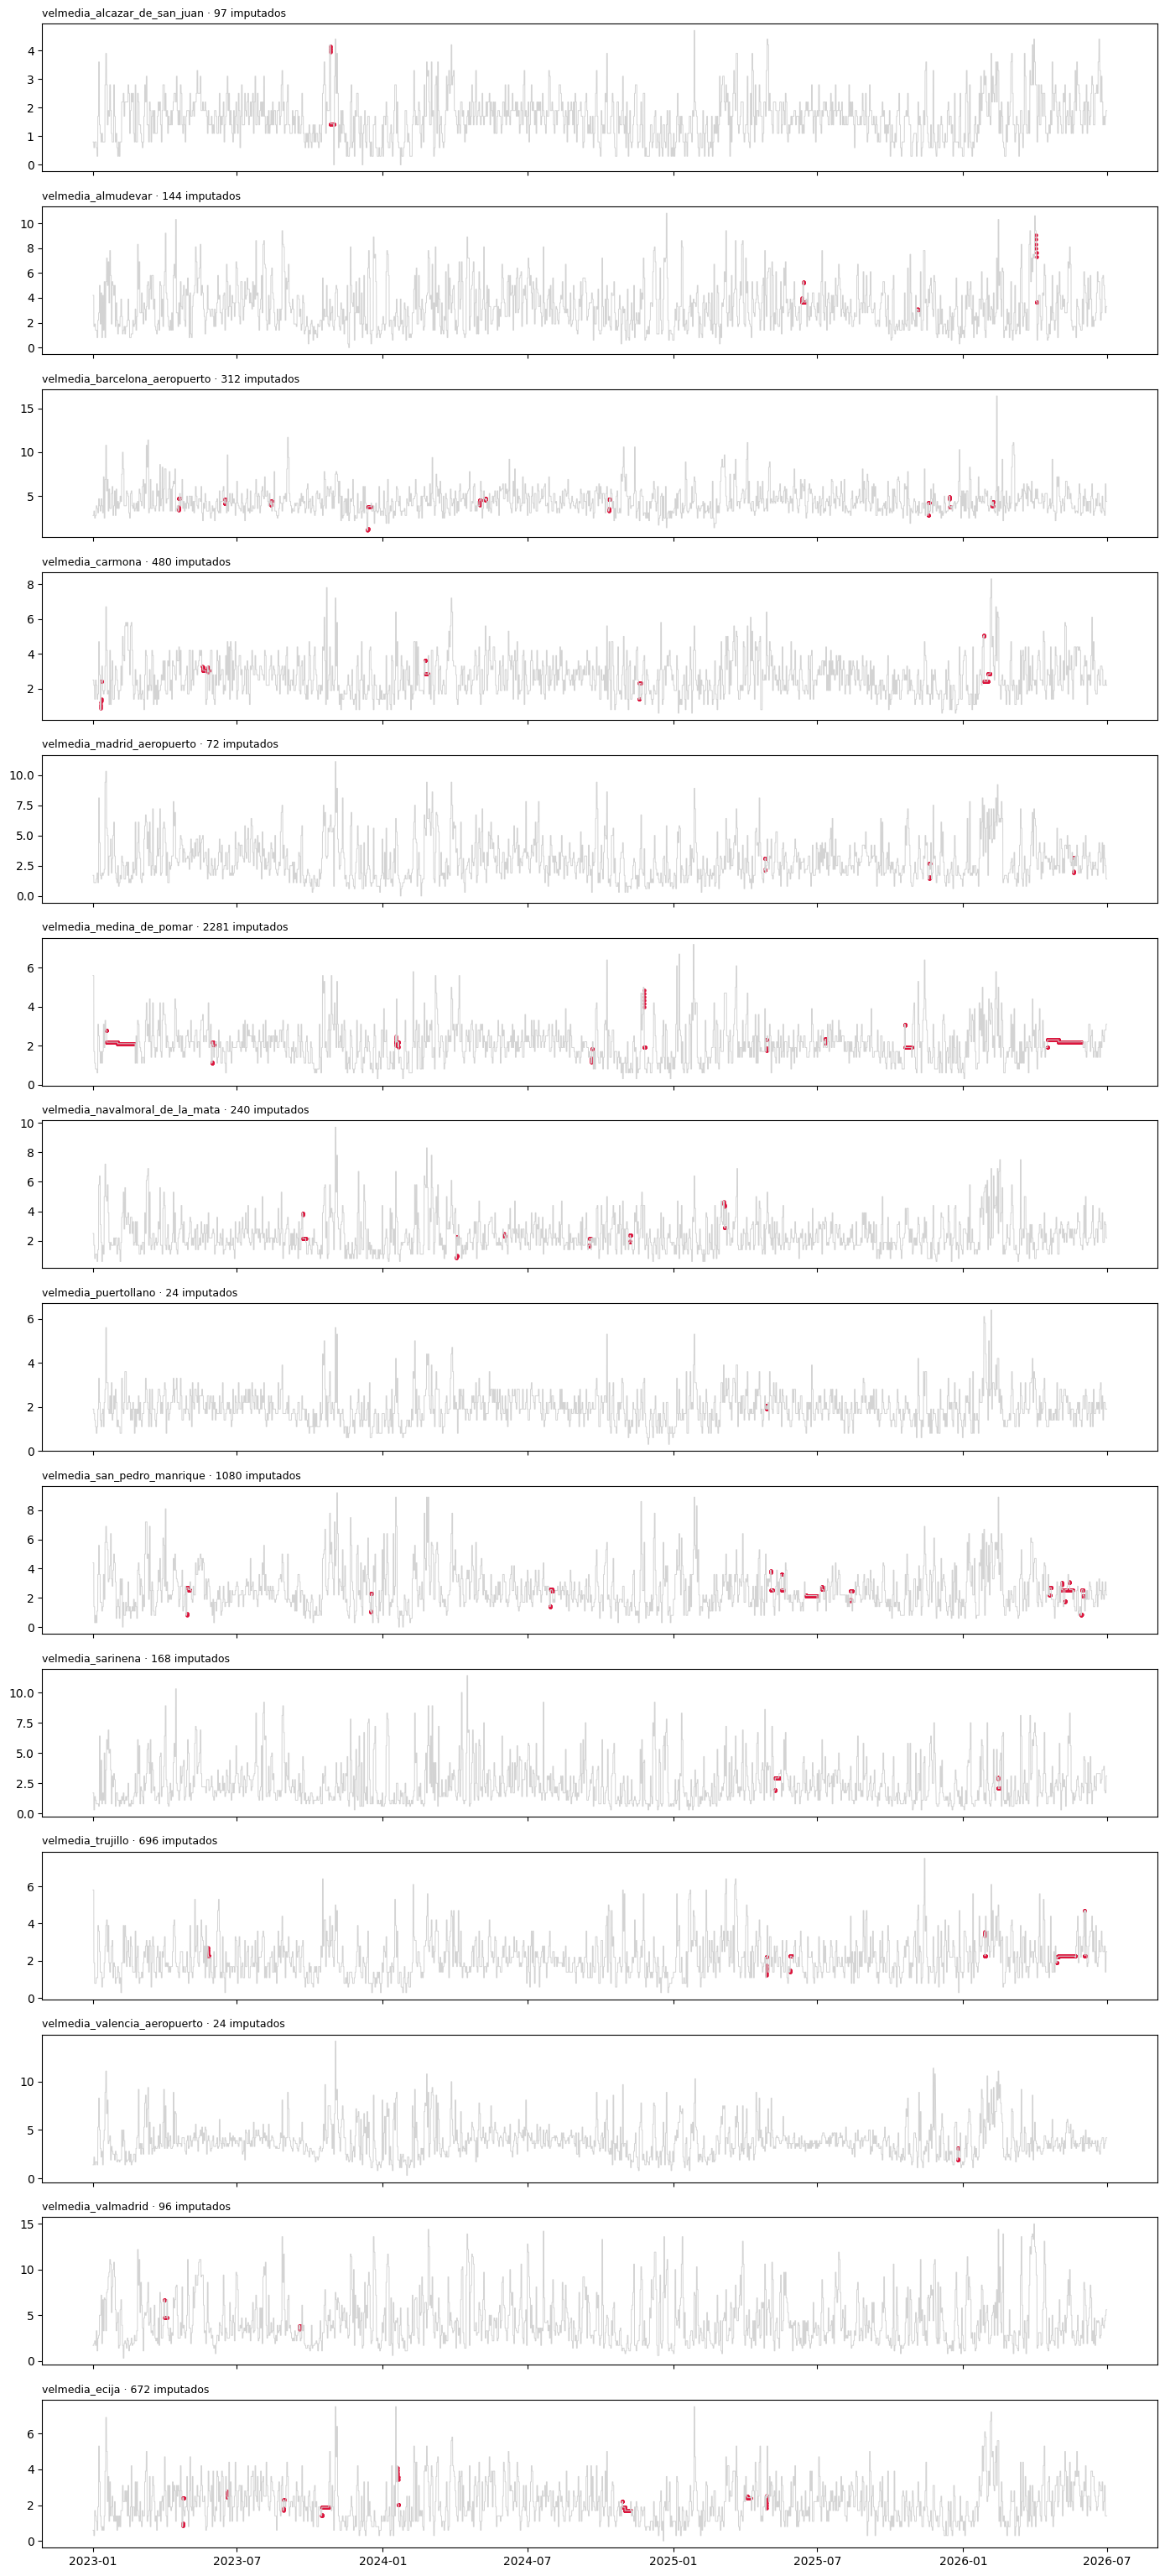

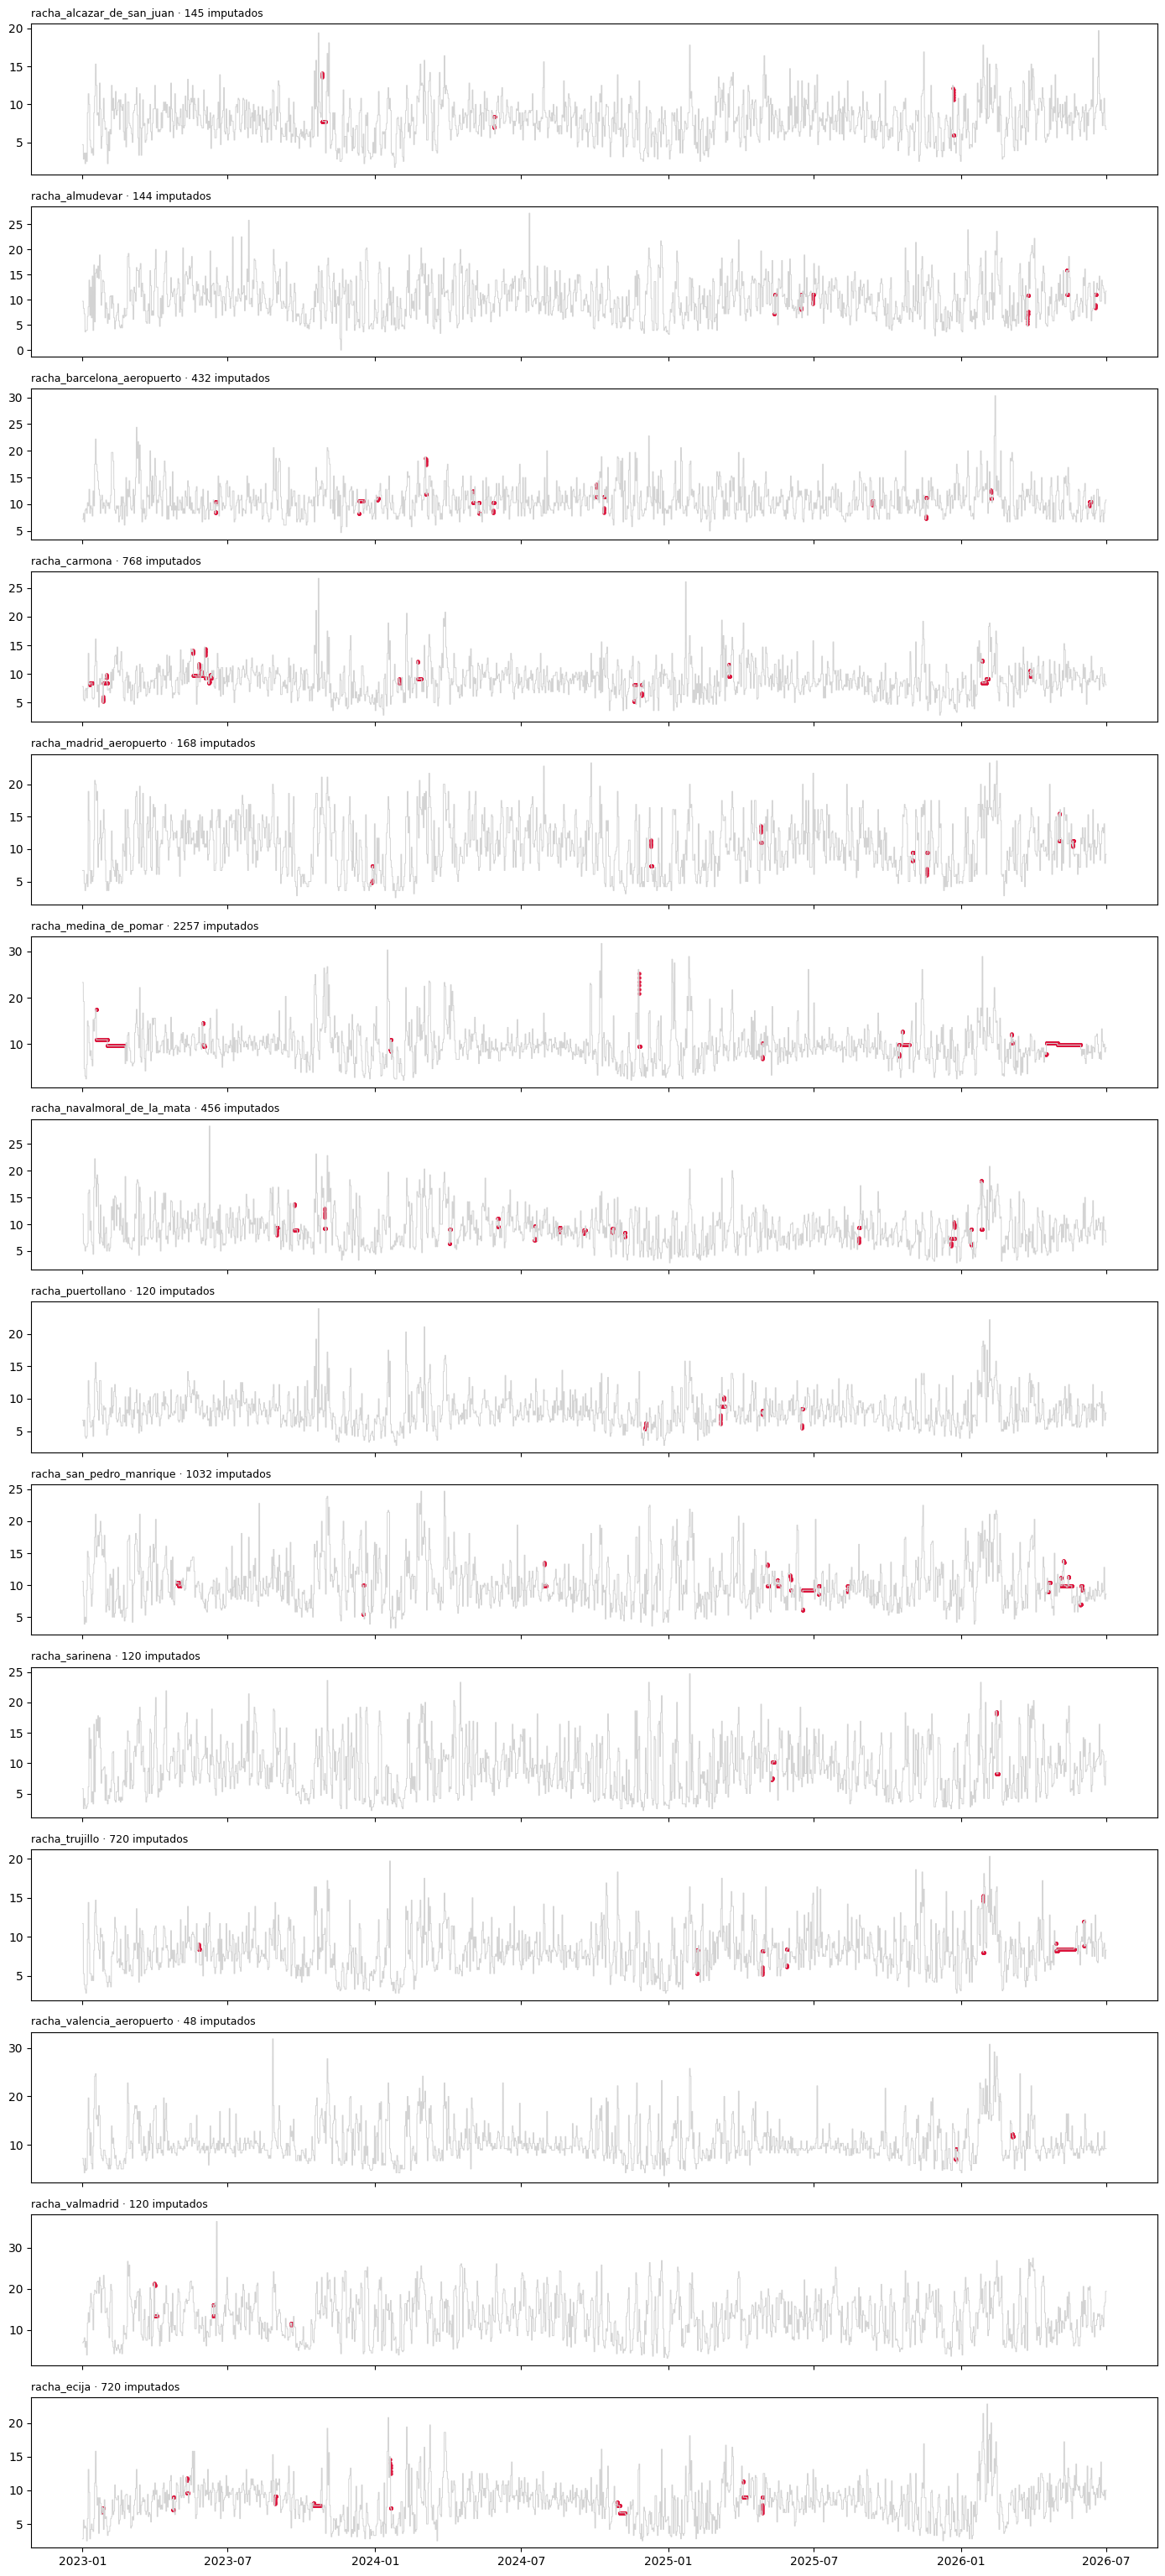

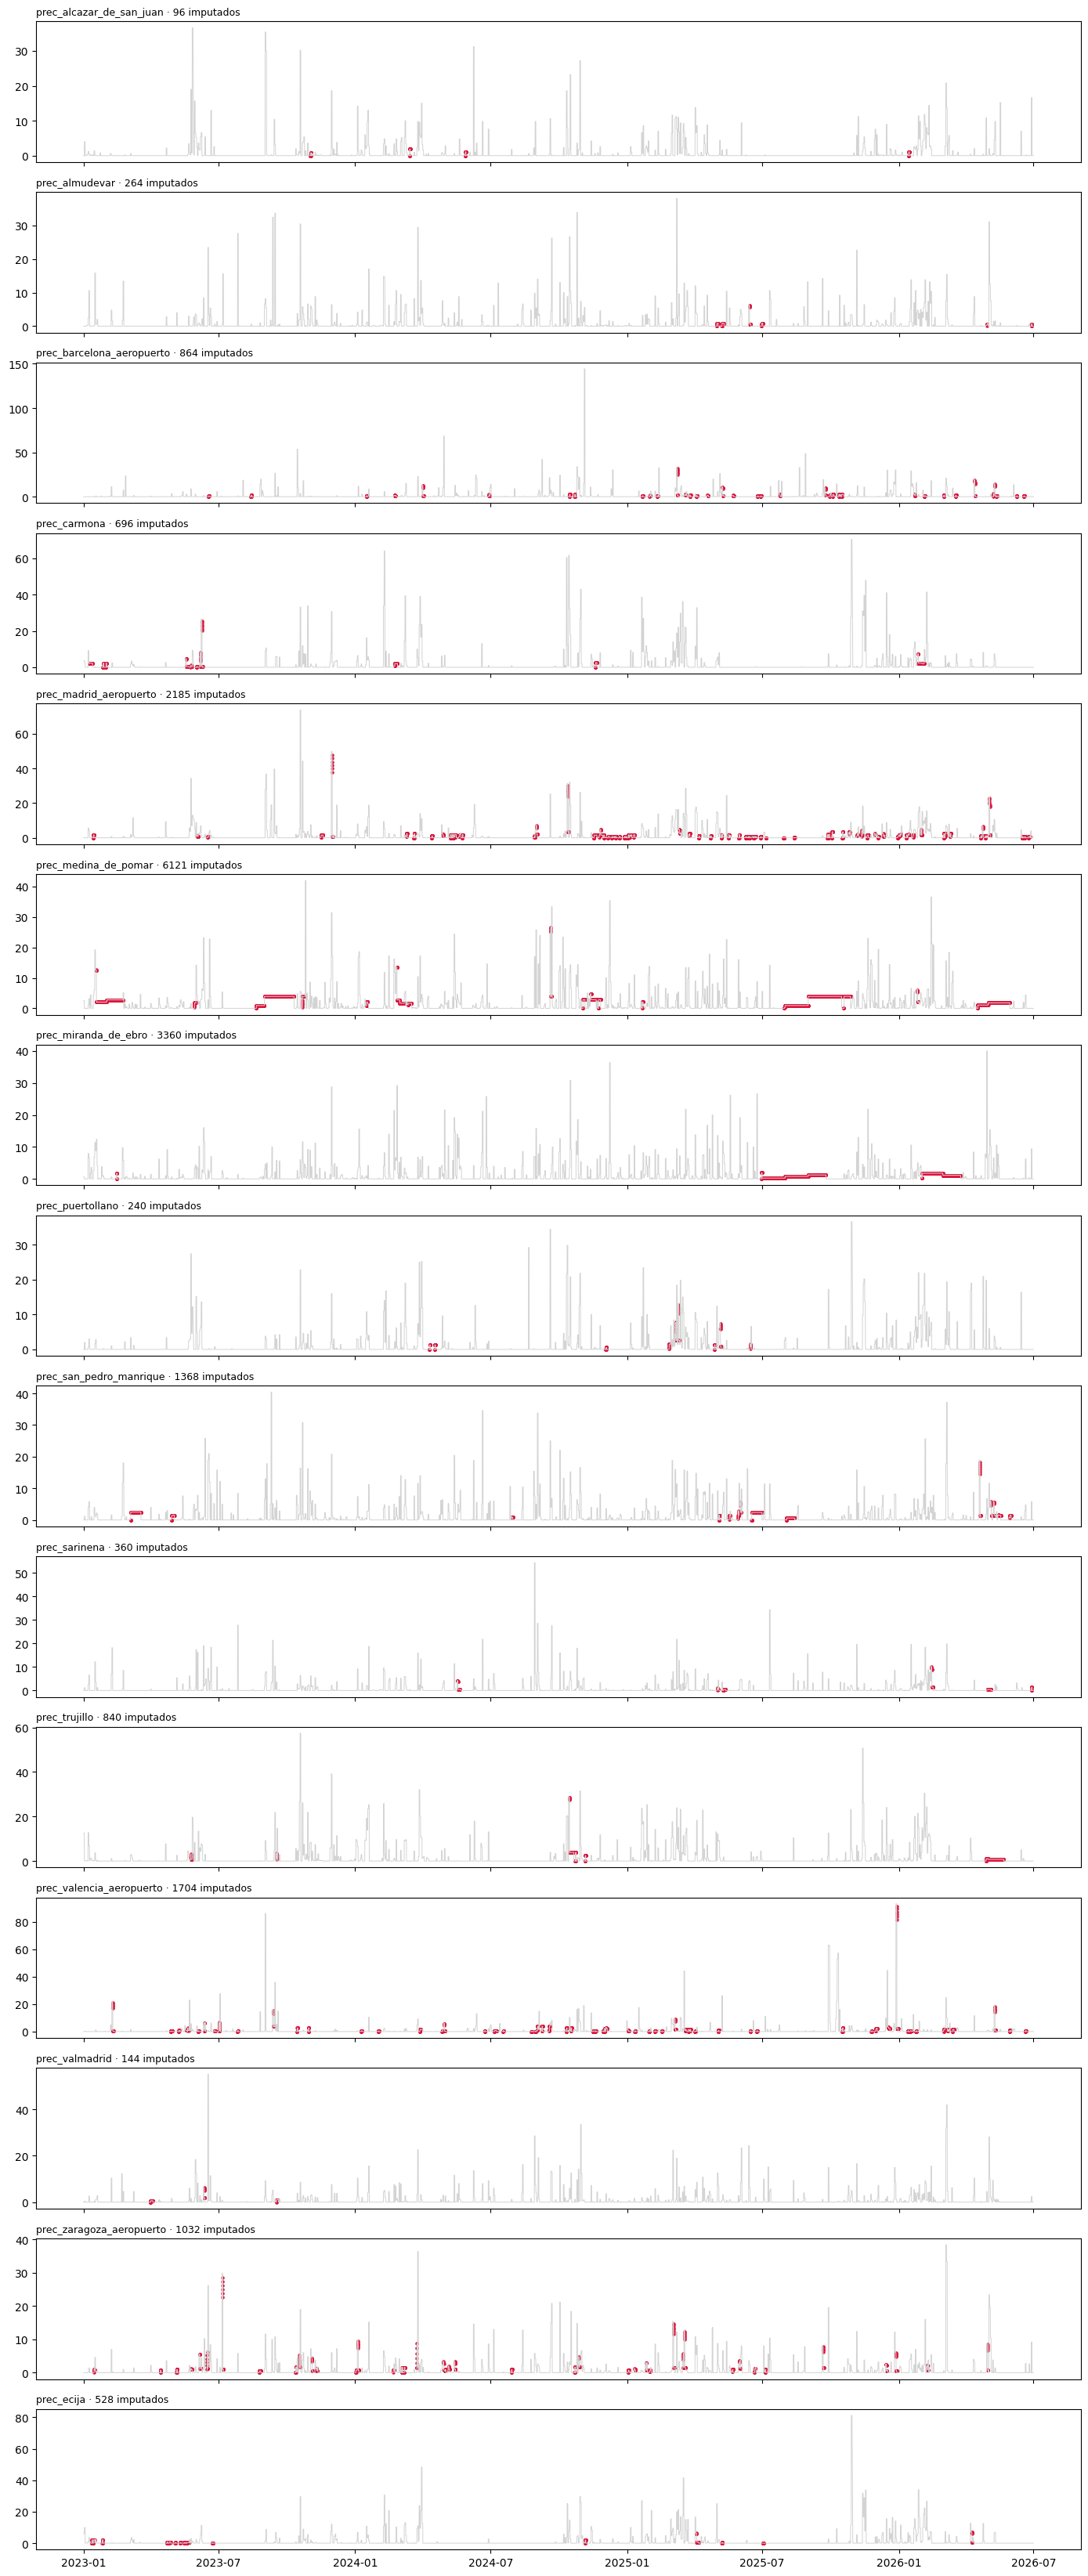

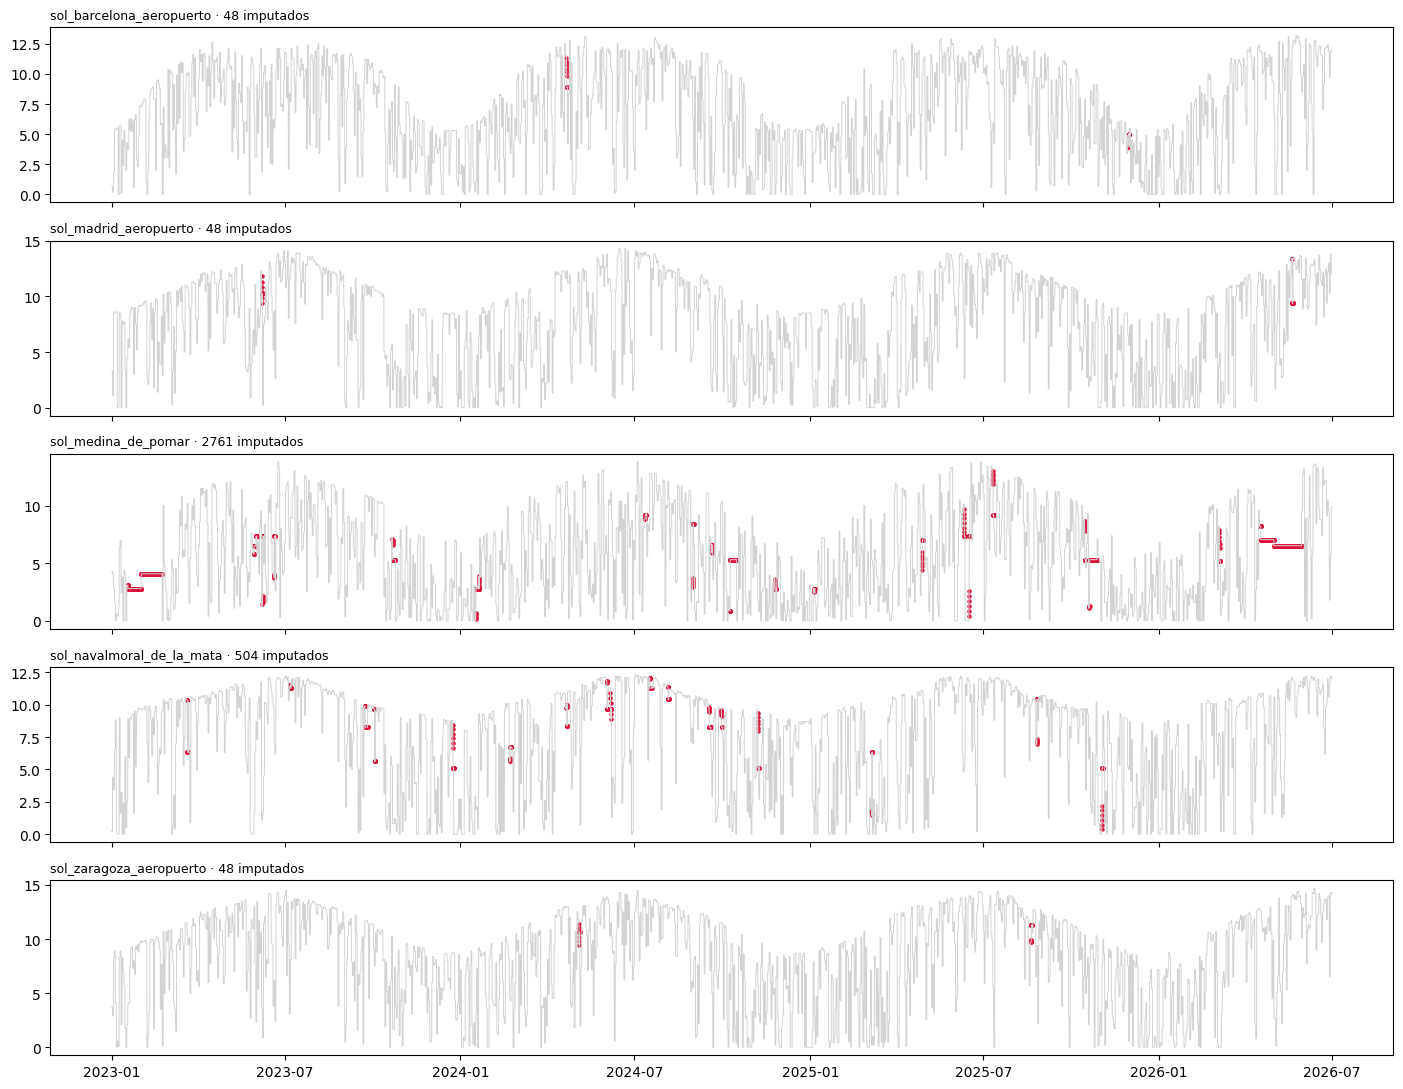

In [58]:
for prefijo in ["tmed_", "tmax_", "velmedia_", "racha_", "prec_", "sol_"]:
    cols = df_copia.columns[df_copia.columns.str.startswith(prefijo)].tolist()
    auditar_imputacion(df, df_copia, cols)

In [59]:
# ── Marca de completitud (modelo predictivo) ──
# Se calcula AQUÍ, tras crear los lags/rolling, para que sus NaN cuenten.
# (Antes se calculaba antes de los lags → filas con precio_lag_168 = NaN quedaban
#  marcadas True. Recalcular tras los lags también captura los huecos que el
#  .map() deja en los días de cambio de hora / DST.)
# Fuera de las features válidas: target, leakage (precio_portugal + *_real,
# reservados al modelo explicativo) y columnas clave/temporales.
excluir = ["precio_espana", "precio_portugal", "datetime_utc", "fecha"]
excluir += df_copia.columns[df_copia.columns.str.endswith("_real")].tolist()

features_validas = df_copia.columns.drop(excluir)

df_copia["completa_features"] = df_copia[features_validas].notna().all(axis=1)
df_copia["entrenable"]        = df_copia["completa_features"] & df_copia["precio_espana"].notna()

df_copia[["completa_features", "entrenable"]].sum()


completa_features    30240
entrenable           30240
dtype: int64

In [60]:

ruta = "../data/processed/tabla_features.parquet"
df_copia.to_parquet(ruta, index=False)

# Verificación rápida de que se guardó bien
comprobar = pd.read_parquet(ruta)
print(comprobar.shape)
print("OK" if comprobar.shape == df_copia.shape else "REVISAR")

(30575, 120)
OK
